# MUR SST L4

The Multi-scale Ultra-high Resolution (MUR) Sea Surface Temperature (SST) Level-4 products provide gap-free, globally gridded analyses by combining multiple satellite and in situ observations using interpolation and data fusion techniques. We will compare 2 MUR products. Both are on a regular grid:

* MUR-JPL-L4-GLOB-v4.1	(~1 km resolution) High-resolution SST	~2002–present
* MUR25-JPL-L4-GLOB-v04.2	(~25 km resolution)	Coarse global SST analysis	~1992–2017 (retrospective)

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are fast. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [ ]:
# if needed
pip install point-collocation

In [ ]:
import earthaccess
earthaccess.login()

## Create some points

Random global over ocean.

In [1]:
import pandas as pd
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/point-collocation/main/"
    "examples/fixtures/points_1000.csv"
)
df_points = pd.read_csv(
    url,
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2015) &
    (df_points["land"] == False)
]
print(len(df))
df.head()

17


,lat,lon,time,land
45,-16.216691,76.119033,2015-04-16,False
52,8.500092,82.677680,2015-07-21,False
251,5.963712,149.291272,2015-02-07,False
377,-10.447214,-155.929463,2015-10-30,False
384,-30.208351,10.304799,2015-01-12,False


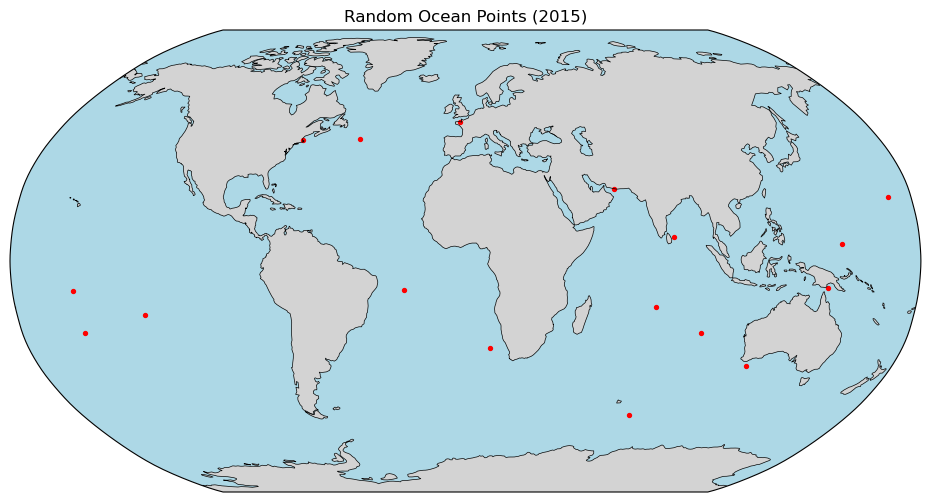

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# create Robinson projection
proj = ccrs.Robinson()

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=proj)

# add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# plot points
ax.scatter(
    df["lon"],
    df["lat"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree()
)

ax.set_global()
plt.title("Random Ocean Points (2015)")
plt.show()

## Make a plan

In [2]:
import point_collocation as pc
short_name="MUR-JPL-L4-GLOB-v4.1"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=1)

Plan: 17 points → 17 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 1 point(s):
  [45] lat=-16.2167, lon=76.1190, time=2015-04-16 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR-JPL-L4-GLOB-v4.1/20150416090000-JPL-L4_GHRSST-SSTfnd-MUR-GLOB-v02.0-fv04.1.nc


## Check out the data first

Hmm, very high resolution.

In [3]:
ds = plan.open_dataset(0)
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',)


<xarray.Dataset> Size: 21GB
Dimensions:           (time: 1, lat: 17999, lon: 36000)
Coordinates:
  * time              (time) datetime64[ns] 8B 2015-01-12T09:00:00
  * lat               (lat) float32 72kB -89.99 -89.98 -89.97 ... 89.98 89.99
  * lon               (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1023, 2047), meta=np.ndarray>
    analysis_error    (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1023, 2047), meta=np.ndarray>
    mask              (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1447, 2895), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1447, 2895), meta=np.ndarray>
    dt_1km_data       (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1447, 2895), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                CF-1.5
    title:                      Daily MUR SST, Final product
    summary:                    A merged, multi-sensor L4 Foundation SST anal...
    references:                 http://podaac.jpl.nasa.gov/Multi-scale_Ultra-...
    institution:                Jet Propulsion Laboratory
    history:                    created at nominal 4-day latency; replaced nr...
    ...                         ...
    project:                    NASA Making Earth Science Data Records for Us...
    publisher_name:             GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L4
    cdm_data_type:              grid

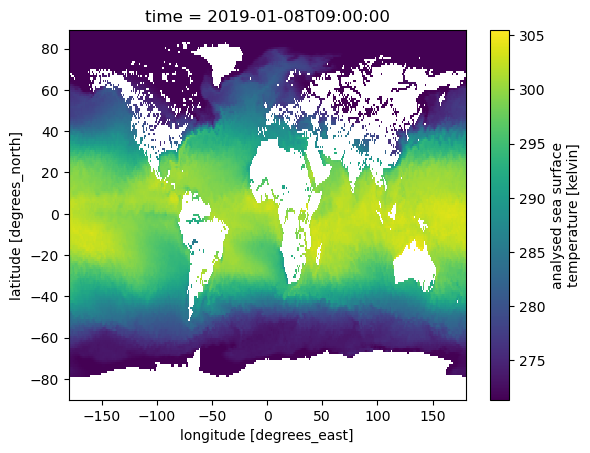

In [5]:
# I am going to heavily coarsen before plotting
(
    ds.analysed_sst
    .coarsen(lat=100, lon=100, boundary="trim")
    .mean()
    .plot()
)

In [4]:
plan.open_dataset(0)

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',)


<xarray.Dataset> Size: 21GB
Dimensions:           (time: 1, lat: 17999, lon: 36000)
Coordinates:
  * time              (time) datetime64[ns] 8B 2015-01-12T09:00:00
  * lat               (lat) float32 72kB -89.99 -89.98 -89.97 ... 89.98 89.99
  * lon               (lon) float32 144kB -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1023, 2047), meta=np.ndarray>
    analysis_error    (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1023, 2047), meta=np.ndarray>
    mask              (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1447, 2895), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1447, 2895), meta=np.ndarray>
    dt_1km_data       (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1447, 2895), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                CF-1.5
    title:                      Daily MUR SST, Final product
    summary:                    A merged, multi-sensor L4 Foundation SST anal...
    references:                 http://podaac.jpl.nasa.gov/Multi-scale_Ultra-...
    institution:                Jet Propulsion Laboratory
    history:                    created at nominal 4-day latency; replaced nr...
    ...                         ...
    project:                    NASA Making Earth Science Data Records for Us...
    publisher_name:             GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L4
    cdm_data_type:              grid

## Everything looks good

Let's try getting the point matchups. This would take about 5 hours on my machine for 10,000 points, but 30 seconds for our small dataset.

In [16]:
%%time
res = pc.matchup(plan, variables = ["sea_ice_fraction", 'analysed_sst', 'analysis_error'])
res

CPU times: user 7.08 s, sys: 862 ms, total: 7.94 s
Wall time: 30.5 s


,lat,lon,time,land,pc_id,granule_id,granule_time,granule_lat,granule_lon,sea_ice_fraction,analysed_sst,analysis_error
0,-16.216691,76.119033,2015-04-16,False,45,https://archive.podaac.earthdata.nasa.gov/poda...,2015-04-16 09:00:00+00:00,-16.219999,76.120003,NaN,301.205,0.39
1,8.500092,82.677680,2015-07-21,False,52,https://archive.podaac.earthdata.nasa.gov/poda...,2015-07-21 09:00:00+00:00,8.500000,82.680000,NaN,302.437,0.41
2,5.963712,149.291272,2015-02-07,False,251,https://archive.podaac.earthdata.nasa.gov/poda...,2015-02-07 09:00:00+00:00,5.960000,149.289993,NaN,303.088,0.41
3,-10.447214,-155.929463,2015-10-30,False,377,https://archive.podaac.earthdata.nasa.gov/poda...,2015-10-30 09:00:00+00:00,-10.450000,-155.929993,NaN,303.332,0.39
4,-30.208351,10.304799,2015-01-12,False,384,https://archive.podaac.earthdata.nasa.gov/poda...,2015-01-12 09:00:00+00:00,-30.209999,10.300000,NaN,294.948,0.37
5,42.798843,-46.120312,2015-09-15,False,396,https://archive.podaac.earthdata.nasa.gov/poda...,2015-09-15 09:00:00+00:00,42.799999,-46.119999,NaN,297.021,0.39
6,22.472809,170.643058,2015-04-09,False,439,https://archive.podaac.earthdata.nasa.gov/poda...,2015-04-09 09:00:00+00:00,22.469999,170.639999,NaN,298.274,0.38
7,-36.603864,118.546812,2015-03-18,False,448,https://archive.podaac.earthdata.nasa.gov/poda...,2015-03-18 09:00:00+00:00,-36.599998,118.550003,NaN,292.872,0.38
8,-10.106711,-24.478649,2015-04-25,False,457,https://archive.podaac.earthdata.nasa.gov/poda...,2015-04-25 09:00:00+00:00,-10.110000,-24.480000,NaN,301.137,0.38
9,-9.514659,143.858933,2015-01-20,False,596,https://archive.podaac.earthdata.nasa.gov/poda...,2015-01-20 09:00:00+00:00,-9.510000,143.860001,NaN,302.679,0.39


## Compare to the low-resolution product

This takes much less time per point since the files are smaller. This would take about an hour on my machine for 10,000 points.

In [5]:
import point_collocation as pc
short_name="MUR25-JPL-L4-GLOB-v04.2"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=1)

Plan: 17 points → 17 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 1 point(s):
  [45] lat=-16.2167, lon=76.1190, time=2015-04-16 00:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/MUR25-JPL-L4-GLOB-v04.2/20150416090000-JPL-L4_GHRSST-SSTfnd-MUR25-GLOB-v02.0-fv04.2.nc


In [6]:
plan.open_dataset(0)

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',)


<xarray.Dataset> Size: 37MB
Dimensions:           (time: 1, lat: 720, lon: 1440)
Coordinates:
  * time              (time) datetime64[ns] 8B 2015-01-12T09:00:00
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    analysed_sst      (time, lat, lon) float64 8MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    analysis_error    (time, lat, lon) float64 8MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    mask              (time, lat, lon) float32 4MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float64 8MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sst_anomaly       (time, lat, lon) float64 8MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/54)
    Conventions:                CF-1.7, ACDD-1.3
    title:                      Daily 0.25-degree MUR SST, Final product
    summary:                    A low-resolution version of the MUR SST analy...
    keywords:                   Oceans > Ocean Temperature > Sea Surface Temp...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    ...                         ...
    publisher_name:             GHRSST Project Office
    publisher_url:              https://www.ghrsst.org
    publisher_email:            gpc@ghrsst.org
    file_quality_level:         3
    metadata_link:              http://podaac.jpl.nasa.gov/ws/metadata/datase...
    acknowledgment:             Please acknowledge the use of these data with...

In [20]:
%%time
res = pc.matchup(plan, variables = ["sea_ice_fraction", 'analysed_sst', 'analysis_error'])
res.head()

CPU times: user 4.31 s, sys: 16.3 ms, total: 4.33 s
Wall time: 6.09 s


,lat,lon,time,land,pc_id,granule_id,granule_time,granule_lat,granule_lon,sea_ice_fraction,analysed_sst,analysis_error
0,-16.216691,76.119033,2015-04-16,False,45,https://archive.podaac.earthdata.nasa.gov/poda...,2015-04-16 09:00:00+00:00,-16.125,76.125,NaN,301.427,0.39
1,8.500092,82.677680,2015-07-21,False,52,https://archive.podaac.earthdata.nasa.gov/poda...,2015-07-21 09:00:00+00:00,8.625,82.625,NaN,302.512,0.41
2,5.963712,149.291272,2015-02-07,False,251,https://archive.podaac.earthdata.nasa.gov/poda...,2015-02-07 09:00:00+00:00,5.875,149.375,NaN,303.106,0.41
3,-10.447214,-155.929463,2015-10-30,False,377,https://archive.podaac.earthdata.nasa.gov/poda...,2015-10-30 09:00:00+00:00,-10.375,-155.875,NaN,303.289,0.39
4,-30.208351,10.304799,2015-01-12,False,384,https://archive.podaac.earthdata.nasa.gov/poda...,2015-01-12 09:00:00+00:00,-30.125,10.375,NaN,294.973,0.37
